In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
print("Shape of dataset:", X.shape)

Shape of dataset: (150, 4)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=2)

In [6]:
X_pca = pca.fit_transform(X_scaled)

In [9]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762]
0.9581320720000163


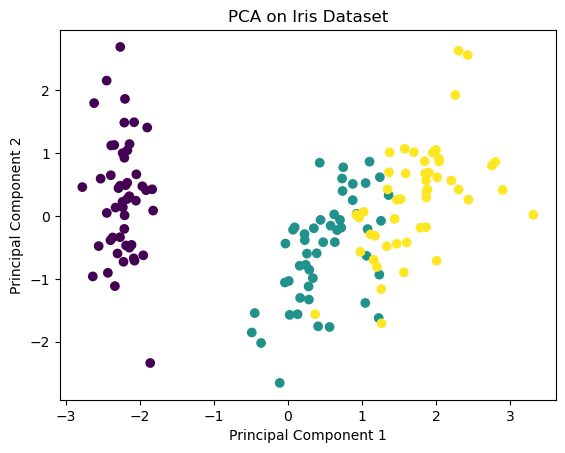

In [8]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.show()

In [10]:
X_reconstructed = pca.inverse_transform(X_pca)
error = np.mean((X_scaled - X_reconstructed)**2)
print("Reconstruction Error:", error)

Reconstruction Error: 0.04186792799998359


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_pca, y)
y_pred = model.predict(X_pca)

print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.9333333333333333
